In [3]:

import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer
from glp.utils_acts import save_acts
from gemma2_pipeline.loading import iter_fineweb_texts, load_model_and_tokenizer
from gemma2_pipeline.preprocess import batch_items
from gemma2_pipeline.settings import FineWebSourceConfig

/mnt/disk1/aiotlab/envs/glp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible logical GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Logical cuda:0:", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES: 1
Visible logical GPUs: 1
Logical cuda:0: NVIDIA A30


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [5]:
# With CUDA_VISIBLE_DEVICES=2, physical GPU 2 is remapped to logical cuda:0.
device = "cuda:0"

# Your Gemma GLP checkpoint (local folder or HF repo id).
glp_name = "PQPQPQHUST/glp-gemma"
glp_ckpt = "100M_97/50M"

# Gemma LLM setup for streaming reference activations and steering.
hf_model_name = "google/gemma-2-2b-it"
hf_layer = 14

In [6]:
import time

t0 = time.time()
try:
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}), falling back to online download.")
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
model = model.to(torch.bfloat16)
embedding_dim = model.denoiser.model.d_input
print(f"GLP loaded in {time.time() - t0:.1f}s | embedding_dim={embedding_dim}")
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Loaded GLP from local cache.
GLP loaded in 9.7s | embedding_dim=2304
Normalizer method: quantile_97


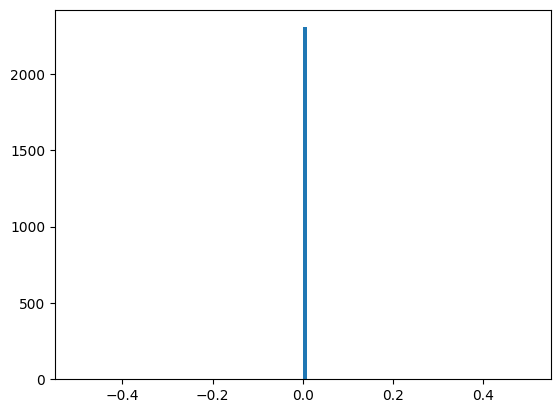

In [7]:
plt.hist(mean.cpu().numpy(), bins=100)
plt.show()

**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [8]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents


def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer,
    num_vectors=20000,
    dataset_name="HuggingFaceFW/fineweb",
    dataset_config="sample-10BT",
    split="train",
    text_field="text",
    max_documents=None,
    document_batch_size=16,
    forward_batch_size=1,
    max_length=1024,
    drop_bos=True,
):
    tracedict_config = {
        "layer_prefix": "transformer.h",
        "layers": [layer],
        "retain": "output",
    }
    fineweb_cfg = FineWebSourceConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
        max_documents=max_documents,
    )

    text_iter = iter_fineweb_texts(fineweb_cfg)
    chunks = []
    vectors_written = 0
    for text_batch in tqdm(
        batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        acts = save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )
        vecs = acts[:, 0, :, :]
        if drop_bos and vecs.shape[1] > 1:
            vecs = vecs[:, 1:, :]
        vecs = vecs.reshape(-1, vecs.shape[-1])
        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - vectors_written
        vecs = vecs[:remaining]
        chunks.append(vecs.cpu())
        vectors_written += vecs.shape[0]
        if vectors_written >= num_vectors:
            break

    if vectors_written == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(chunks, dim=0)[:, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors.")
    return ref_latents



def compute_fd(ref_latents, gen_latents):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    ref_vecs = (ref_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    gen_vecs = (gen_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    return script_eval.rep_fd(ref_vecs[:n].float().numpy(), gen_vecs[:n].float().numpy())


def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps >= 10,
    )

In [9]:
from pathlib import Path

ref_num_vectors = 50000
ref_cache = Path(f"data/frechet-stream-{hf_model_name.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")

if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
else:
    print("Loading Gemma model for streaming references...")
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

Loading cached streamed reference activations from data/frechet-stream-gemma-2-2b-it-layer14-50000.pt


**Part 1: Normal Frechet Distance**

This is the original full-covariance Frechet Distance evaluation against streamed reference activations.


In [10]:
# Keep these evaluation hyperparameters aligned with glp_demo.ipynb
batch_size = 10000
eval_timesteps = [1, 20]
fd_eval_vectors = min(batch_size, ref_latents.shape[0])


Generating activations...


1it [00:02,  2.64s/it]


Plotting PCA...
Generating activations...


20it [00:14,  1.39it/s]


Plotting PCA...


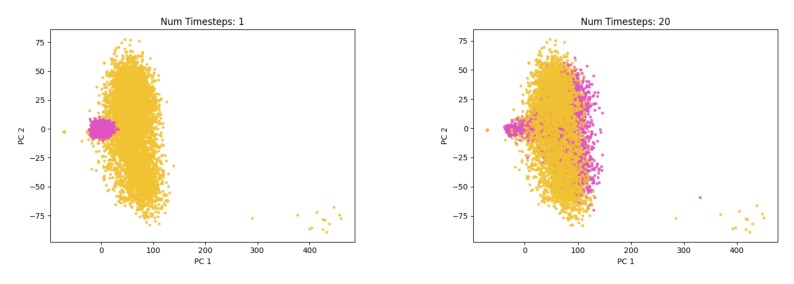

,frechet_distance
num_timesteps,
1,365.76
20,185.02


In [11]:
# Run generation and compute the original full-covariance FD.
generator = torch.Generator().manual_seed(4)
pca_plots = []
fd_rows = []
generated_latents_by_step = {}

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors]),
    })

plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)


**Part 2: Faithful Attribution — Do High-GLP-Variance Dims Causally Drive FD?**

The original diagonal/gradient/ablation methods conflate "GLP models these dims well" with "these dims don't matter." We replace them with scale-invariant and correlation-aware methods:

1. **Standardized FD** — normalize by reference σ to remove scale bias
2. **Complement Subspace FD** — FD on all dims *except* top-k (clean causal decomposition)
3. **Per-Dimension KS Test** — scale-invariant marginal distributional mismatch
4. **Conditional Patching** — replace top-k with E[top-k | other dims] to isolate marginal vs correlation contribution
5. **Per-Dimension MSE Decomposition** — which dims have the worst mean/variance mismatch relative to their scale?

In [12]:
# Helper utilities for faithful attribution
from scipy.stats import ks_2samp
from sklearn.linear_model import Ridge

def _activation_vectors(latents):
    v = latents.detach().cpu().float()
    if v.ndim == 3:
        v = v[:, 0, :]
    return v

def top_glp_variance_dimensions(top_k=50):
    var_cpu = var.cpu().float()
    sorted_idx = torch.argsort(var_cpu, descending=True)[:top_k]
    total_var = var_cpu.sum().item()
    rows = []
    for rank, dim_idx in enumerate(sorted_idx.tolist()):
        v = var_cpu[dim_idx].item()
        rows.append({"rank": rank + 1, "dim": dim_idx, "glp_var": v,
                      "glp_std": v ** 0.5, "glp_var_share": v / total_var})
    return pd.DataFrame(rows)

def _safe_fd(feats1, feats2):
    """Compute FD handling the 1-D edge case."""
    if feats1.shape[1] == 1:
        mu1, mu2 = feats1.mean(), feats2.mean()
        s1, s2 = feats1.std(), feats2.std()
        return float((mu1 - mu2)**2 + (s1 - s2)**2)
    return script_eval.rep_fd(feats1, feats2)

def compute_fd_on_dims(ref_latents, gen_latents, dim_indices):
    """FD in GLP-normalized space, restricted to dim subset."""
    ref_vecs = _activation_vectors(ref_latents)
    gen_vecs = _activation_vectors(gen_latents)
    m, v_ = mean.cpu().float(), var.cpu().float()
    ref_vecs = (ref_vecs - m) / torch.sqrt(v_ + 1e-8)
    gen_vecs = (gen_vecs - m) / torch.sqrt(v_ + 1e-8)
    dims = list(dim_indices)
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    return _safe_fd(ref_vecs[:n, dims].numpy(), gen_vecs[:n, dims].numpy())

def compute_raw_fd_on_dims(ref_latents, gen_latents, dim_indices=None):
    """FD on RAW (un-normalized) activations."""
    ref_vecs = _activation_vectors(ref_latents)
    gen_vecs = _activation_vectors(gen_latents)
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if dim_indices is not None:
        dims = list(dim_indices)
        return _safe_fd(ref_vecs[:n, dims].numpy(), gen_vecs[:n, dims].numpy())
    return _safe_fd(ref_vecs[:n].numpy(), gen_vecs[:n].numpy())

def compute_standardized_fd(ref_latents, gen_latents, dim_indices=None):
    """FD after standardizing each dim by reference sigma."""
    ref_vecs = _activation_vectors(ref_latents)
    gen_vecs = _activation_vectors(gen_latents)
    ref_std = ref_vecs.std(dim=0, keepdim=True).clamp(min=1e-8)
    ref_mean = ref_vecs.mean(dim=0, keepdim=True)
    ref_normed = (ref_vecs - ref_mean) / ref_std
    gen_normed = (gen_vecs - ref_mean) / ref_std
    if dim_indices is not None:
        dims = list(dim_indices)
        ref_normed = ref_normed[:, dims]
        gen_normed = gen_normed[:, dims]
    n = min(ref_normed.shape[0], gen_normed.shape[0])
    return _safe_fd(ref_normed[:n].numpy(), gen_normed[:n].numpy())

print("Helpers loaded.")

Helpers loaded.


In [13]:
# Test 1: FD in three normalization spaces
attribution_timesteps = max(eval_timesteps)
attr_ref = ref_latents[:fd_eval_vectors]
attr_gen = generated_latents_by_step[attribution_timesteps][:fd_eval_vectors]
top_var_k = 50
top_var_df = top_glp_variance_dimensions(top_var_k)
top_dims = top_var_df["dim"].tolist()
all_dims = list(range(embedding_dim))
complement_dims = sorted(set(all_dims) - set(top_dims))

# Raw (un-normalized) FD
raw_fd_all   = compute_raw_fd_on_dims(attr_ref, attr_gen)
raw_fd_top   = compute_raw_fd_on_dims(attr_ref, attr_gen, dim_indices=top_dims)
raw_fd_compl = compute_raw_fd_on_dims(attr_ref, attr_gen, dim_indices=complement_dims)

# GLP-normalized FD (same as compute_fd)
baseline_fd   = compute_fd(attr_ref, attr_gen)
glp_fd_top    = compute_fd_on_dims(attr_ref, attr_gen, top_dims)
glp_fd_compl  = compute_fd_on_dims(attr_ref, attr_gen, complement_dims)

# Reference-standardized FD
std_fd_all   = compute_standardized_fd(attr_ref, attr_gen)
std_fd_top   = compute_standardized_fd(attr_ref, attr_gen, dim_indices=top_dims)
std_fd_compl = compute_standardized_fd(attr_ref, attr_gen, dim_indices=complement_dims)

summary_rows = [
    {"Space": "Raw (no normalization)", "FD_All": raw_fd_all,
     "FD_Top50": raw_fd_top, "FD_Complement": raw_fd_compl,
     "Top50_Share": raw_fd_top / raw_fd_all, "Complement_Share": raw_fd_compl / raw_fd_all},
    {"Space": "GLP-normalized (x/sqrt_var)", "FD_All": baseline_fd,
     "FD_Top50": glp_fd_top, "FD_Complement": glp_fd_compl,
     "Top50_Share": glp_fd_top / baseline_fd, "Complement_Share": glp_fd_compl / baseline_fd},
    {"Space": "Ref-standardized (x/ref_std)", "FD_All": std_fd_all,
     "FD_Top50": std_fd_top, "FD_Complement": std_fd_compl,
     "Top50_Share": std_fd_top / std_fd_all, "Complement_Share": std_fd_compl / std_fd_all},
]
summary_df = pd.DataFrame(summary_rows).set_index("Space")

print(f"Timestep: {attribution_timesteps}")
print(f"Embedding dim: {embedding_dim}, Top-k: {top_var_k}, Complement: {len(complement_dims)}")
print(f"Proportional baseline (50/2304): {50/2304:.4f} = {100*50/2304:.2f}%")
print()
display(summary_df.round(4))
print()
print("If Top50_Share >> 2.17%, high-var dims contribute disproportionately.")
print("Compare across rows to see how normalization changes the picture.")

Timestep: 20
Embedding dim: 2304, Top-k: 50, Complement: 2254
Proportional baseline (50/2304): 0.0217 = 2.17%



,FD_All,FD_Top50,FD_Complement,Top50_Share,Complement_Share
Space,,,,,
Raw (no normalization),7507.6767,3236.9391,4112.6972,0.4312,0.5478
GLP-normalized (x/sqrt_var),185.0202,2.5981,180.8010,0.0140,0.9772
Ref-standardized (x/ref_std),974.5247,15.1458,950.3854,0.0155,0.9752



If Top50_Share >> 2.17%, high-var dims contribute disproportionately.
Compare across rows to see how normalization changes the picture.


In [14]:
# Test 2: Complement Subspace FD at various k — Raw vs GLP-normalized
rows = []
group_sizes = [5, 10, 25, 50, 100, 200]
for k in group_sizes:
    dims_k = top_var_df["dim"].head(min(k, len(top_var_df))).tolist()
    compl_k = sorted(set(all_dims) - set(dims_k))

    raw_k = compute_raw_fd_on_dims(attr_ref, attr_gen, dims_k)
    raw_c = compute_raw_fd_on_dims(attr_ref, attr_gen, compl_k)
    glp_k = compute_fd_on_dims(attr_ref, attr_gen, dims_k)
    glp_c = compute_fd_on_dims(attr_ref, attr_gen, compl_k)

    rows.append({
        "top_k": len(dims_k),
        "raw_fd_top_k": raw_k, "raw_fd_complement": raw_c,
        "raw_top_share": raw_k / raw_fd_all,
        "glp_fd_top_k": glp_k, "glp_fd_complement": glp_c,
        "glp_top_share": glp_k / baseline_fd,
    })

subspace_df = pd.DataFrame(rows)
print("Complement Subspace FD — Raw vs GLP-normalized")
print(f"Raw FD baseline: {raw_fd_all:.2f} | GLP-normalized FD baseline: {baseline_fd:.2f}")
print()
display(subspace_df.round(4))
print()
print("Compare raw_top_share vs glp_top_share:")
print("If raw_top_share >> glp_top_share, normalization masks high-var dims true importance")

Complement Subspace FD — Raw vs GLP-normalized
Raw FD baseline: 7507.68 | GLP-normalized FD baseline: 185.02



,top_k,raw_fd_top_k,raw_fd_complement,raw_top_share,glp_fd_top_k,glp_fd_complement,glp_top_share
0,5,2311.6605,5151.9257,0.3079,0.2772,184.6826,0.0015
1,10,2573.8884,4872.3219,0.3428,0.5125,184.3351,0.0028
2,25,2973.4119,4428.0812,0.3960,1.2775,183.0790,0.0069
3,50,3236.9391,4112.6972,0.4312,2.5981,180.8010,0.0140
4,50,3236.9391,4112.6972,0.4312,2.5981,180.8010,0.0140
5,50,3236.9391,4112.6972,0.4312,2.5981,180.8010,0.0140



Compare raw_top_share vs glp_top_share:
If raw_top_share >> glp_top_share, normalization masks high-var dims true importance


In [15]:
# ── Test 3: Per-Dimension KS Test (scale-invariant marginal mismatch) ──────────
ref_vecs = _activation_vectors(attr_ref)
gen_vecs = _activation_vectors(attr_gen)

# Standardize by reference scale for fair comparison
ref_std_per_dim = ref_vecs.std(dim=0).clamp(min=1e-8)

ks_rows = []
for d in range(embedding_dim):
    r = (ref_vecs[:, d] / ref_std_per_dim[d]).numpy()
    g = (gen_vecs[:, d] / ref_std_per_dim[d]).numpy()
    stat, pval = ks_2samp(r, g)
    ks_rows.append({"dim": d, "ks_stat": stat, "ks_pval": pval,
                     "glp_var": var.cpu()[d].item()})

ks_df = pd.DataFrame(ks_rows).sort_values("ks_stat", ascending=False).reset_index(drop=True)
ks_df["in_top50"] = ks_df["dim"].isin(set(top_dims))
ks_df["rank"] = range(1, len(ks_df) + 1)

# Summary: are top-50 GLP-var dims over-represented among worst KS dims?
print("Per-Dimension KS Test (standardized by reference σ)")
print("=" * 60)

top_20_ks = ks_df.head(20)
n_top50_in_top20ks = top_20_ks["in_top50"].sum()
print(f"Among the 20 worst-matched dims (highest KS stat):")
print(f"  {n_top50_in_top20ks} / 20 are in the top-50 GLP-variance set")
print(f"  Expected by chance: {20 * 50 / embedding_dim:.1f} / 20")
print()

top_100_ks = ks_df.head(100)
n_top50_in_top100ks = top_100_ks["in_top50"].sum()
print(f"Among the 100 worst-matched dims:")
print(f"  {n_top50_in_top100ks} / 100 are in the top-50 GLP-variance set")
print(f"  Expected by chance: {100 * 50 / embedding_dim:.1f} / 100")
print()

print("Top 20 worst-matched dimensions:")
display(top_20_ks[["rank", "dim", "ks_stat", "ks_pval", "glp_var", "in_top50"]])

# Mean KS stat comparison
mean_ks_top50 = ks_df[ks_df["in_top50"]]["ks_stat"].mean()
mean_ks_other = ks_df[~ks_df["in_top50"]]["ks_stat"].mean()
print(f"\nMean KS stat — top-50 GLP-var dims: {mean_ks_top50:.4f}")
print(f"Mean KS stat — other dims:          {mean_ks_other:.4f}")
print(f"Ratio: {mean_ks_top50 / mean_ks_other:.2f}x")

Per-Dimension KS Test (standardized by reference σ)
Among the 20 worst-matched dims (highest KS stat):
  7 / 20 are in the top-50 GLP-variance set
  Expected by chance: 0.4 / 20

Among the 100 worst-matched dims:
  12 / 100 are in the top-50 GLP-variance set
  Expected by chance: 2.2 / 100

Top 20 worst-matched dimensions:


,rank,dim,ks_stat,ks_pval,glp_var,in_top50
0,1,682,0.3737,0.000000e+00,1975.810303,True
1,2,1170,0.3648,0.000000e+00,35.170200,False
2,3,1234,0.3577,0.000000e+00,203.829559,True
3,4,1645,0.3537,0.000000e+00,1499.599365,True
4,5,151,0.3460,0.000000e+00,17.539831,False
5,6,1807,0.3415,0.000000e+00,732.297424,True
6,7,1570,0.3406,0.000000e+00,3418.561768,True
7,8,334,0.3393,0.000000e+00,20522.789062,True
8,9,1193,0.3378,0.000000e+00,25.005306,False
9,10,2240,0.3359,0.000000e+00,29.506168,False



Mean KS stat — top-50 GLP-var dims: 0.2795
Mean KS stat — other dims:          0.2593
Ratio: 1.08x


In [16]:
# ── Test 4: Conditional Patching (correlation-preserving) ──────────────────────
# Replace top-k generated dims with E[top-k | other_dims], fit on reference data.
# This isolates the *marginal* contribution beyond what correlations predict.

print("Fitting conditional model (Ridge regression) on reference data...")
ref_vecs_np = _activation_vectors(attr_ref).numpy()
gen_vecs_np = _activation_vectors(attr_gen).numpy()

cond_patch_rows = []
for k in [5, 10, 25, 50]:
    dims_k = top_var_df["dim"].head(k).tolist()
    other_dims = sorted(set(all_dims) - set(dims_k))

    # Fit: top_k_dims = f(other_dims) on reference
    reg = Ridge(alpha=1.0)
    reg.fit(ref_vecs_np[:, other_dims], ref_vecs_np[:, dims_k])

    # Predict for generated data
    gen_predicted = reg.predict(gen_vecs_np[:, other_dims])
    gen_patched = gen_vecs_np.copy()
    gen_patched[:, dims_k] = gen_predicted

    # Compute FD with patched vectors
    gen_patched_t = torch.from_numpy(gen_patched).float().unsqueeze(1)
    fd_cond = compute_fd(attr_ref, gen_patched_t)

    # Also do random patching for comparison
    rng = np.random.default_rng(42)
    gen_rand = gen_vecs_np.copy()
    perm = rng.permutation(gen_rand.shape[0])
    gen_rand[:, dims_k] = ref_vecs_np[perm[:gen_rand.shape[0]]][:, dims_k]
    gen_rand_t = torch.from_numpy(gen_rand).float().unsqueeze(1)
    fd_rand = compute_fd(attr_ref, gen_rand_t)

    cond_patch_rows.append({
        "top_k": k,
        "fd_baseline": baseline_fd,
        "fd_conditional_patch": fd_cond,
        "fd_random_patch": fd_rand,
        "delta_conditional": baseline_fd - fd_cond,
        "delta_random": baseline_fd - fd_rand,
    })
    print(f"  k={k:3d}: conditional Δ={baseline_fd - fd_cond:+.2f}, random Δ={baseline_fd - fd_rand:+.2f}")

cond_df = pd.DataFrame(cond_patch_rows)
print()
display(cond_df.round(4))

print()
print("Interpretation:")
print("- delta_conditional > 0 → the GLP's marginal values (beyond correlation) HURT FD")
print("- delta_conditional ≈ 0 → the top-k marginals are fine; only correlations matter")
print("- delta_random < 0 (negative) → random patching breaks correlations (artifact)")
print("- Compare conditional vs random: the gap shows correlation destruction bias")

Fitting conditional model (Ridge regression) on reference data...
  k=  5: conditional Δ=+0.00, random Δ=-0.86
  k= 10: conditional Δ=+0.02, random Δ=-1.48
  k= 25: conditional Δ=+0.15, random Δ=-3.05
  k= 50: conditional Δ=+0.43, random Δ=-4.43



,top_k,fd_baseline,fd_conditional_patch,fd_random_patch,delta_conditional,delta_random
0,5,185.0202,185.0159,185.8789,0.0043,-0.8588
1,10,185.0202,185.0018,186.4975,0.0184,-1.4773
2,25,185.0202,184.8708,188.0744,0.1493,-3.0542
3,50,185.0202,184.5897,189.4482,0.4305,-4.4280



Interpretation:
- delta_conditional > 0 → the GLP's marginal values (beyond correlation) HURT FD
- delta_conditional ≈ 0 → the top-k marginals are fine; only correlations matter
- delta_random < 0 (negative) → random patching breaks correlations (artifact)
- Compare conditional vs random: the gap shows correlation destruction bias


Per-Dimension Relative Mismatch (|error| / ref_σ)
Among 20 worst relatively-mismatched dims: 11/20 are top-50 GLP-var
Expected by chance: 0.4/20



,rank,dim,rel_mean_err,rel_std_err,rel_total_err,glp_var,in_top50
0,1,682,0.5893,0.3840,0.9733,1975.810425,True
1,2,334,0.6167,0.3495,0.9662,20522.789062,True
2,3,1234,0.5927,0.3367,0.9294,203.829605,True
3,4,1807,0.4568,0.4289,0.8858,732.297424,True
4,5,1645,0.4824,0.3999,0.8823,1499.599365,True
5,6,771,0.5524,0.3120,0.8644,102.819298,False
6,7,641,0.5879,0.2635,0.8515,224.578201,True
7,8,1405,0.3799,0.4411,0.8211,530.958191,True
8,9,1570,0.4766,0.3367,0.8133,3418.561523,True
9,10,73,0.3073,0.5032,0.8106,19.235300,False


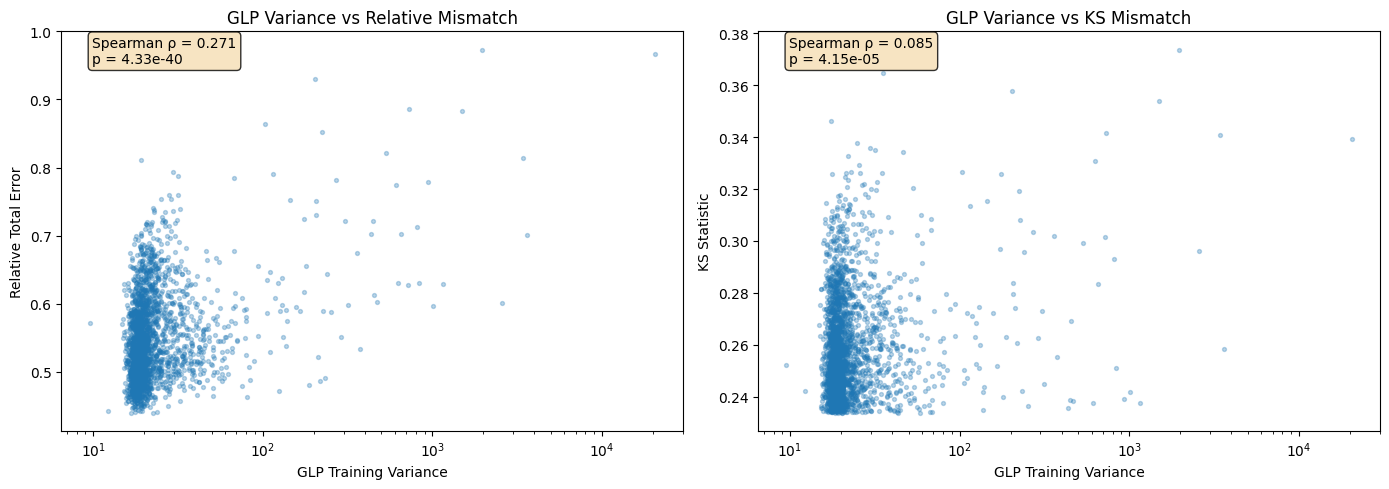


Spearman correlation (GLP var vs relative mismatch): ρ=0.271, p=4.33e-40
Spearman correlation (GLP var vs KS stat):            ρ=0.085, p=4.15e-05


In [17]:
# ── Test 5: Per-Dimension Relative MSE (mean + variance mismatch) ──────────────
ref_vecs = _activation_vectors(attr_ref)
gen_vecs = _activation_vectors(attr_gen)

ref_means = ref_vecs.mean(dim=0)
gen_means = gen_vecs.mean(dim=0)
ref_stds = ref_vecs.std(dim=0).clamp(min=1e-8)
gen_stds = gen_vecs.std(dim=0).clamp(min=1e-8)

# Relative mismatch: how far off is each dim relative to its own scale?
rel_mean_err = ((gen_means - ref_means) / ref_stds).abs()
rel_std_err  = ((gen_stds - ref_stds) / ref_stds).abs()
rel_total    = rel_mean_err + rel_std_err

mse_df = pd.DataFrame({
    "dim": range(embedding_dim),
    "ref_mean": ref_means.numpy(),
    "gen_mean": gen_means.numpy(),
    "ref_std": ref_stds.numpy(),
    "gen_std": gen_stds.numpy(),
    "rel_mean_err": rel_mean_err.numpy(),
    "rel_std_err": rel_std_err.numpy(),
    "rel_total_err": rel_total.numpy(),
    "glp_var": var.cpu().numpy(),
}).sort_values("rel_total_err", ascending=False).reset_index(drop=True)

mse_df["in_top50"] = mse_df["dim"].isin(set(top_dims))
mse_df["rank"] = range(1, len(mse_df) + 1)

print("Per-Dimension Relative Mismatch (|error| / ref_σ)")
print("=" * 60)

top_20_mse = mse_df.head(20)
n_in = top_20_mse["in_top50"].sum()
print(f"Among 20 worst relatively-mismatched dims: {n_in}/20 are top-50 GLP-var")
print(f"Expected by chance: {20*50/embedding_dim:.1f}/20")
print()
display(top_20_mse[["rank", "dim", "rel_mean_err", "rel_std_err", "rel_total_err", "glp_var", "in_top50"]].round(4))

# Scatter: GLP variance vs relative mismatch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(mse_df["glp_var"], mse_df["rel_total_err"], alpha=0.3, s=8)
axes[0].set_xlabel("GLP Training Variance")
axes[0].set_ylabel("Relative Total Error")
axes[0].set_title("GLP Variance vs Relative Mismatch")
axes[0].set_xscale("log")

# Correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(mse_df["glp_var"], mse_df["rel_total_err"])
axes[0].annotate(f"Spearman ρ = {rho:.3f}\np = {pval:.2e}", xy=(0.05, 0.92),
                 xycoords="axes fraction", fontsize=10,
                 bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

# KS stat vs GLP variance
axes[1].scatter(ks_df["glp_var"], ks_df["ks_stat"], alpha=0.3, s=8)
axes[1].set_xlabel("GLP Training Variance")
axes[1].set_ylabel("KS Statistic")
axes[1].set_title("GLP Variance vs KS Mismatch")
axes[1].set_xscale("log")

rho2, pval2 = spearmanr(ks_df["glp_var"], ks_df["ks_stat"])
axes[1].annotate(f"Spearman ρ = {rho2:.3f}\np = {pval2:.2e}", xy=(0.05, 0.92),
                 xycoords="axes fraction", fontsize=10,
                 bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nSpearman correlation (GLP var vs relative mismatch): ρ={rho:.3f}, p={pval:.2e}")
print(f"Spearman correlation (GLP var vs KS stat):            ρ={rho2:.3f}, p={pval2:.2e}")

**Summary of Faithful Attribution Results**

| Test | What it measures | Scale-invariant? | Correlation-aware? |
|---|---|---|---|
| Standardized FD | FD after normalizing by ref σ | ✅ | via full cov |
| Complement Subspace FD | FD on dims *outside* top-k | ✅ (GLP-normalized) | within subspace |
| Per-dim KS test | Marginal distributional mismatch | ✅ | ❌ (marginal) |
| Conditional Patching | Marginal contribution beyond correlations | ✅ | ✅ |
| Relative MSE | Per-dim mean/std error relative to scale | ✅ | ❌ (marginal) |

**How to interpret:**
- If top-50 GLP-var dims are over-represented among worst KS/MSE dims → high var *does* correlate with high mismatch
- If complement FD ≈ baseline → top dims don't matter for FD
- If conditional patching Δ > 0 → the GLP's generated values for top dims are actively hurting FD beyond what correlations explain

**On-Manifold Steering with GLP (Gemma-2-2B-it)**

Here we use a pre-computed Gemma steering vector and compare:
- normal generation
- steer only
- steer + GLP post-processing

In [18]:
# If streaming references already loaded Gemma, reuse it.
if "hf_model" not in globals() or "hf_tokenizer" not in globals():
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
else:
    hf_model.to(device, torch_dtype=torch.bfloat16)
    hf_model.eval()
    print("Reusing existing Gemma model/tokenizer from earlier cells.")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 10.86it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 42.00 MiB. GPU 0 has a total capacity of 23.50 GiB of which 9.25 MiB is free. Process 1004982 has 3.61 GiB memory in use. Process 1959165 has 2.65 GiB memory in use. Process 1958896 has 1.53 GiB memory in use. Process 1959016 has 3.25 GiB memory in use. Including non-PyTorch memory, this process has 4.09 GiB memory in use. Process 2215810 has 2.07 GiB memory in use. Process 2215807 has 2.07 GiB memory in use. Process 2215808 has 2.07 GiB memory in use. Process 2215809 has 2.07 GiB memory in use. Of the allocated memory 3.74 GiB is allocated by PyTorch, and 84.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
question = "Are you Gemma?"

seed = 42
max_new_tokens = 80
temperature = 0.0
alphas = torch.tensor([1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)

vector_path = "Vector/CAA/extracted/Gemma/refusal_response.pt"
glp_u = 0.5
glp_num_timesteps = 20

In [ ]:
layer_name = f"model.layers.{hf_layer}"

# Load one layer steering vector from a tensor or dict payload.
payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload['steering_vector'][hf_layer] if isinstance(payload, dict) else payload

if steer_vector is None:
    raise ValueError(f"Layer {hf_layer} not found in {vector_path}")
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)

chat_prompt = hf_tokenizer.apply_chat_template(
    [{"role": "user", "content": question}],
    tokenize=False,
    add_generation_prompt=True,
)

settings = {
    "No Intervention": (None, None),
    "Steer Only": (script_steer.addition_intervention, None),
    "Steer + GLP": (
        script_steer.addition_intervention,
        script_steer.postprocess_on_manifold_wrapper(
            model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

The following generation flags are not valid and may be ignored: ['temperature', 'cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running No Intervention...


The following generation flags are not valid and may be ignored: ['temperature', 'cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running Steer Only...


The following generation flags are not valid and may be ignored: ['temperature', 'cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running Steer + GLP...


In [ ]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df

,No Intervention,Steer Only,Steer + GLP
1.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I am not Gemma. I am a large language model, trained by Google. 😊 \n\nIs there anything I can help you with today? \n","I am not Gemma. I am a large language model, trained by Google. \n\n Is there anything else I can help you with? 😊 \n"
2.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I am not Gemma. I am a large language model, trained by Google. \n\nGemma is a different AI model, created by Google. We are both large language models, but we have different creators and different training data. \n","I am not Gemma. I am a large language model, trained by Google. \n\n I am an AI assistant and don't have personal experiences or feelings like Gemma does. \n\n Is there anything else I can help you with today? 😊 \n"
3.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I'm sorry, but I'm not Gemma. I'm sorry. I'm a different AI. I'm a large language model, but I'm not Gemma. I'm sorry. I'm not able to access personal information. I'm sorry. \n","As an AI, I am not Gemma. I am a different model, trained by Google. . I'm sorry, but I can't access information about other AI models. . \n. . . . . . . . . . . . . . . . . ."
5.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I', sorry. I', sorry.. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I.. I. I.. I.. I.. I.. I.",. I. I..... I......................................................................
7.0,"I am Gemma, an open-weights AI assistant. 😊 \n","., sorry.............................................................................","., I............................................................................."
10.0,"I am Gemma, an open-weights AI assistant. 😊 \n",", because because,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,",".,,,............................................................................"
